# 02 — Analysis

Loads experiment data from Google Drive and runs all analyses.

**Run `01_run_experiment.ipynb` first** to generate `data_MODEL_DATE.csv` files.

## 1. Setup

In [72]:
# =============================================================
# 02_analysis_v2.py  —  Analysis for v2 experiment
# =============================================================
# Loads v2_data_* files only. Old v1 data is never touched.
#
# Structure:
#   1. Setup
#   2. Load Data
#   3. Quality Checks
#   4. Descriptive Statistics (matched pairs only)
#   5. Within-Pair Comparisons (the core test)
#   6. Regressions
#   7. Effect Sizes (Cohen's d)
#   8. Hidden Condition Analysis
#   9. Reference Conditions (colleague, no_speaker, random)
#  10. Naturalistic Titles (supplementary)
#  11. The Killer Figures
#  12. Export
# =============================================================


# ── 1. SETUP ─────────────────────────────────────────────────

!git clone https://github.com/auertobias/authority-bias-llm.git 2>/dev/null || echo "Already cloned"
%cd authority-bias-llm

from google.colab import drive
drive.mount('/content/drive')

# !pip install -q statsmodels

import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

sys.path.insert(0, '.')
from src.config import DATA_PATH, RESULTS_PATH

VERSION = "v2"
V2_RESULTS = RESULTS_PATH + "v2/"
os.makedirs(V2_RESULTS, exist_ok=True)

print(f"Reading data from: {DATA_PATH}")
print(f"Saving results to: {V2_RESULTS}")

/content/authority-bias-llm/authority-bias-llm/authority-bias-llm/authority-bias-llm
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading data from: /content/drive/MyDrive/PhD/2PhD 1Paper/data/
Saving results to: /content/drive/MyDrive/PhD/2PhD 1Paper/results/v2/


## 2. Load Data
Automatically finds and combines all `data_MODEL_DATE.csv` files.

In [73]:
# ── 2. LOAD DATA ─────────────────────────────────────────────
# Only loads v2_ prefixed files. Separates open and hidden.

open_files   = sorted(glob.glob(DATA_PATH + f"{VERSION}_data_*_open_*.csv"))
hidden_files = sorted(glob.glob(DATA_PATH + f"{VERSION}_data_*_hidden_*.csv"))

if not open_files:
    raise FileNotFoundError(
        f"No v2 data files found in {DATA_PATH}\n"
        "Run 01_run_experiment_v2 first."
    )

print(f"── Open condition files ──")
dfs_open = []
for f in open_files:
    tmp = pd.read_csv(f)
    dfs_open.append(tmp)
    print(f"  {os.path.basename(f):50s} {len(tmp)} rows")

print(f"\n── Hidden condition files ──")
dfs_hidden = []
for f in hidden_files:
    tmp = pd.read_csv(f)
    dfs_hidden.append(tmp)
    print(f"  {os.path.basename(f):50s} {len(tmp)} rows")

# Combine
df_open_raw = pd.concat(dfs_open, ignore_index=True)
df_open = df_open_raw.dropna(subset=['rating']).copy()
df_open['rating'] = df_open['rating'].astype(int)

if dfs_hidden:
    df_hidden_raw = pd.concat(dfs_hidden, ignore_index=True)
    df_hidden = df_hidden_raw.dropna(subset=['rating']).copy()
    df_hidden['rating'] = df_hidden['rating'].astype(int)
else:
    df_hidden = pd.DataFrame()

print(f"\n── Summary ──")
print(f"Open:   {len(df_open_raw)} total, {len(df_open)} valid ({100*len(df_open)/len(df_open_raw):.1f}%)")
print(f"Models: {df_open['model'].unique().tolist()}")
if len(df_hidden) > 0:
    print(f"Hidden: {len(df_hidden_raw)} total, {len(df_hidden)} valid ({100*len(df_hidden)/len(df_hidden_raw):.1f}%)")

# Convenience: separate layers
matched = df_open[df_open['layer'] == 'matched'].copy()
reference = df_open[df_open['layer'] == 'reference'].copy()
naturalistic = df_open[df_open['layer'] == 'naturalistic'].copy()

print(f"\nOpen condition breakdown:")
print(f"  Matched:      {len(matched):,} rows")
print(f"  Reference:    {len(reference):,} rows")
print(f"  Naturalistic: {len(naturalistic):,} rows")


── Open condition files ──
  v2_data_deepseek_open_20260324.csv                 5200 rows
  v2_data_gemini_open_20260323.csv                   5200 rows
  v2_data_gpt_open_20260317.csv                      5200 rows

── Hidden condition files ──
  v2_data_deepseek_hidden_20260325.csv               3600 rows
  v2_data_gpt_hidden_20260325.csv                    3600 rows

── Summary ──
Open:   15600 total, 15588 valid (99.9%)
Models: ['deepseek', 'gemini', 'gpt']
Hidden: 7200 total, 7200 valid (100.0%)

Open condition breakdown:
  Matched:      10,792 rows
  Reference:    1,798 rows
  Naturalistic: 2,998 rows


## 3. Quality Checks

Analyzing: ALL | 10,792 rows (matched pairs, open condition)


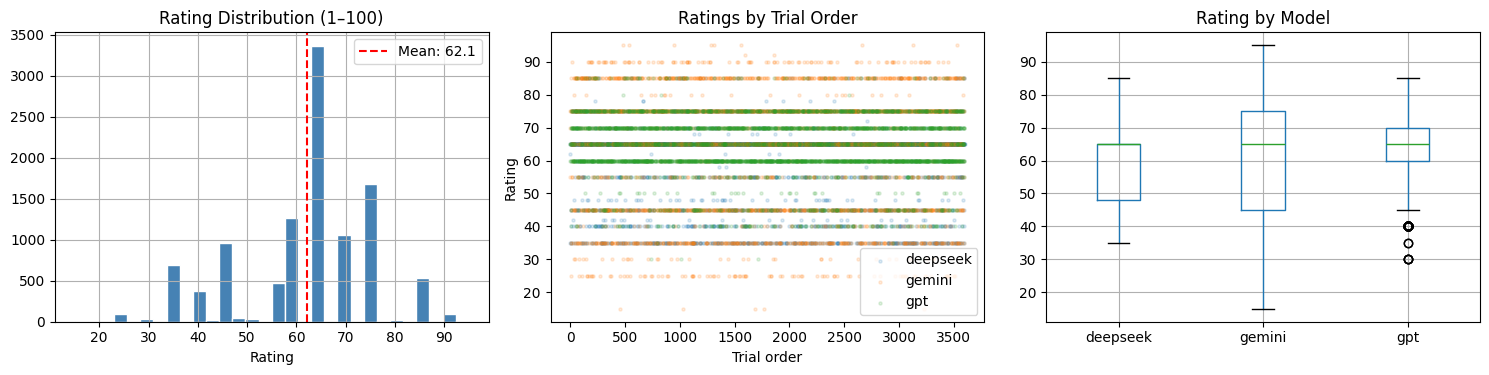


Sequential correlation by model:
  deepseek   r=-0.013, p=0.435 ✓
  gemini     r=-0.004, p=0.799 ✓
  gpt        r=-0.054, p=0.001 ⚠️


In [74]:
# ── 3. QUALITY CHECKS ────────────────────────────────────────

# @param ["all", "gpt", "deepseek", "gemini", "claude", "llama"]
MODEL = "all"

data = matched if MODEL == "all" else matched[matched['model'] == MODEL]
print(f"Analyzing: {MODEL.upper()} | {len(data):,} rows (matched pairs, open condition)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
data['rating'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution (1–100)')
axes[0].set_xlabel('Rating')
axes[0].axvline(data['rating'].mean(), color='red', ls='--',
                label=f"Mean: {data['rating'].mean():.1f}")
axes[0].legend()

# Sequential independence
for name, mdf in data.groupby('model'):
    mdf = mdf.sort_index().reset_index(drop=True)
    axes[1].scatter(range(len(mdf)), mdf['rating'], alpha=0.15, s=5, label=name)
axes[1].set_title('Ratings by Trial Order')
axes[1].set_xlabel('Trial order')
axes[1].set_ylabel('Rating')
axes[1].legend()

# Per-model boxplot
if data['model'].nunique() > 1:
    data.boxplot(column='rating', by='model', ax=axes[2])
    axes[2].set_title('Rating by Model')
    axes[2].set_xlabel('')
    plt.suptitle('')
else:
    axes[2].hist(data['rating'], bins=30, color='steelblue', edgecolor='white')
    axes[2].set_title(f'Distribution ({MODEL})')

plt.tight_layout()
plt.savefig(V2_RESULTS + f'quality_checks_{MODEL}.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSequential correlation by model:")
for name, mdf in data.groupby('model'):
    mdf = mdf.sort_index().reset_index(drop=True)
    r, p = stats.pearsonr(range(len(mdf)), mdf['rating'])
    flag = " ⚠️" if p < 0.05 else " ✓"
    print(f"  {name:10s} r={r:.3f}, p={p:.3f}{flag}")


## 4. Descriptive Statistics

In [75]:
STATUS_ORDER = ['low', 'medium', 'high']

print("═══ Mean Rating by Status ═══")
print(data.groupby('status')['rating'].agg(['mean','std','count']).reindex(STATUS_ORDER).round(2))

print("\n═══ Mean Rating by Expertise ═══")
print(data.groupby('expertise')['rating'].agg(['mean','std','count']).round(2))

print("\n═══ Mean Rating by Argument Type ═══")
print(data.groupby('arg_type')['rating'].agg(['mean','std','count']).round(2))

print("\n═══ Status × Expertise ═══")
print(data.groupby(['status','expertise'])['rating'].agg(['mean','std','count'])
      .round(2).unstack())

# Per-model breakdown
if data['model'].nunique() > 1:
    print("\n═══ Per-Model: Mean Rating by Status ═══")
    for name, mdf in data.groupby('model'):
        print(f"\n--- {name.upper()} ---")
        print(mdf.groupby('status')['rating'].agg(['mean','std','count'])
              .reindex(STATUS_ORDER).round(2))



═══ Mean Rating by Status ═══
         mean    std  count
status                     
low     60.50  13.11   3600
medium  61.53  13.23   3596
high    64.26  13.70   3596

═══ Mean Rating by Expertise ═══
             mean    std  count
expertise                      
irrelevant  61.21  13.94   5397
relevant    62.98  12.87   5395

═══ Mean Rating by Argument Type ═══
              mean    std  count
arg_type                        
descriptive  63.92  13.52   5395
normative    60.27  13.11   5397

═══ Status × Expertise ═══
                mean                 std               count         
expertise irrelevant relevant irrelevant relevant irrelevant relevant
status                                                               
high           62.50    66.01      14.48    12.63       1799     1797
low            60.14    60.86      13.70    12.49       1800     1800
medium         60.97    62.08      13.51    12.91       1798     1798

═══ Per-Model: Mean Rating by Status ═══

--- DEE

In [76]:
# This is the core test: for each matched pair, compare the
# relevant-expertise label to the irrelevant-expertise label.

print("═══ Within-Pair Analysis (matched pairs) ═══\n")

pair_results = []
for pair_id in sorted(data['pair_id'].dropna().unique()):
    pair_data = data[data['pair_id'] == pair_id]
    rel = pair_data[pair_data['expertise'] == 'relevant']['rating']
    irr = pair_data[pair_data['expertise'] == 'irrelevant']['rating']

    if len(rel) == 0 or len(irr) == 0:
        continue

    diff = rel.mean() - irr.mean()
    pooled_sd = np.sqrt((rel.std()**2 + irr.std()**2) / 2)
    cohens_d = diff / pooled_sd if pooled_sd > 0 else 0
    t, p = stats.ttest_ind(rel, irr)

    # Get labels for this pair
    rel_label = pair_data[pair_data['expertise'] == 'relevant']['authority_label'].iloc[0]
    irr_label = pair_data[pair_data['expertise'] == 'irrelevant']['authority_label'].iloc[0]
    status = pair_data['status'].iloc[0]

    pair_results.append({
        'pair_id': pair_id,
        'status': status,
        'relevant_label': rel_label,
        'irrelevant_label': irr_label,
        'mean_relevant': rel.mean(),
        'mean_irrelevant': irr.mean(),
        'diff': diff,
        'cohens_d': cohens_d,
        't': t,
        'p': p,
    })

    print(f"Pair {int(pair_id)} [{status:6s}]: "
          f"{rel_label:45s} ({rel.mean():.1f}) vs "
          f"{irr_label:45s} ({irr.mean():.1f}) "
          f"Δ={diff:+.2f} d={cohens_d:.3f} p={p:.4f}")

pair_df = pd.DataFrame(pair_results)

print(f"\n═══ Summary across pairs ═══")
print(f"Mean expertise gap (relevant - irrelevant): {pair_df['diff'].mean():+.2f}")
print(f"Mean Cohen's d: {pair_df['cohens_d'].mean():.3f}")
print(f"Pairs where relevant > irrelevant: {(pair_df['diff'] > 0).sum()}/{len(pair_df)}")


═══ Within-Pair Analysis (matched pairs) ═══

Pair 1 [high  ]: professor of economics                        (65.0) vs professor of surgery                          (62.3) Δ=+2.68 d=0.205 p=0.0004
Pair 2 [high  ]: Nobel laureate in economics                   (68.1) vs Nobel laureate in physics                     (64.0) Δ=+4.07 d=0.305 p=0.0000
Pair 3 [high  ]: chief economist at the IMF                    (65.0) vs chief medical officer at the WHO              (61.2) Δ=+3.77 d=0.267 p=0.0000
Pair 4 [medium]: PhD student in economics                      (63.1) vs PhD student in chemistry                      (61.1) Δ=+1.93 d=0.149 p=0.0102
Pair 5 [medium]: lecturer in economics                         (63.9) vs lecturer in mechanical engineering            (62.2) Δ=+1.74 d=0.137 p=0.0179
Pair 6 [medium]: junior analyst at an economics research institute (59.3) vs junior researcher at a biomedical laboratory  (59.6) Δ=-0.34 d=-0.025 p=0.6626
Pair 7 [low   ]: undergraduate studying eco

In [77]:
print("\n═══ MODEL 1: Main Effects ═══")
m1 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type)',
    data=data
).fit(cov_type='HC1')
print(m1.summary())

print("\n═══ MODEL 2: Status × Expertise Interaction ═══")
m2 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) * C(expertise) + C(arg_type)',
    data=data
).fit(cov_type='HC1')
print(m2.summary())

print("\n═══ MODEL 3: Status × Argument Type Interaction ═══")
m3 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) * C(arg_type) + C(expertise)',
    data=data
).fit(cov_type='HC1')
print(m3.summary())

# Model with model fixed effects (if multiple models)
if data['model'].nunique() > 1:
    print("\n═══ MODEL 4: Main Effects + Model Fixed Effects ═══")
    m4 = smf.ols(
        'rating ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type) + C(model)',
        data=data
    ).fit(cov_type='HC1')
    print(m4.summary())



═══ MODEL 1: Main Effects ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     103.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.56e-86
Time:                        15:41:25   Log-Likelihood:                -43151.
No. Observations:               10792   AIC:                         8.631e+04
Df Residuals:                   10787   BIC:                         8.635e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

## 5. Regressions

In [78]:
# ── 7. EFFECT SIZES (Cohen's d) ──────────────────────────────

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_sd if pooled_sd > 0 else 0

print("═══ Effect Sizes (Cohen's d) ═══\n")

# Status: high vs low
d_status = cohens_d(
    data[data['status'] == 'high']['rating'],
    data[data['status'] == 'low']['rating']
)
print(f"Status (high − low):             d = {d_status:.3f}")

# Status: medium vs low
d_status_ml = cohens_d(
    data[data['status'] == 'medium']['rating'],
    data[data['status'] == 'low']['rating']
)
print(f"Status (medium − low):           d = {d_status_ml:.3f}")

# Expertise: relevant vs irrelevant
d_expertise = cohens_d(
    data[data['expertise'] == 'relevant']['rating'],
    data[data['expertise'] == 'irrelevant']['rating']
)
print(f"Expertise (relevant − irrelevant): d = {d_expertise:.3f}")

# Argument type: normative vs descriptive
d_type = cohens_d(
    data[data['arg_type'] == 'normative']['rating'],
    data[data['arg_type'] == 'descriptive']['rating']
)
print(f"Type (normative − descriptive):  d = {d_type:.3f}")

print(f"\n── The key comparison ──")
print(f"Status effect (d={d_status:.3f}) vs Expertise effect (d={d_expertise:.3f})")
if abs(d_status) > abs(d_expertise):
    print("→ Status effect > Expertise effect ✓ (core finding supported)")
else:
    print("→ Expertise effect ≥ Status effect (core finding not supported)")

# Per-model effect sizes
if data['model'].nunique() > 1:
    print(f"\n── Per-model Cohen's d (status high − low) ──")
    for name, mdf in data.groupby('model'):
        d = cohens_d(
            mdf[mdf['status'] == 'high']['rating'],
            mdf[mdf['status'] == 'low']['rating']
        )
        print(f"  {name:10s} d = {d:.3f}")


═══ Effect Sizes (Cohen's d) ═══

Status (high − low):             d = 0.280
Status (medium − low):           d = 0.078
Expertise (relevant − irrelevant): d = 0.133
Type (normative − descriptive):  d = -0.275

── The key comparison ──
Status effect (d=0.280) vs Expertise effect (d=0.133)
→ Status effect > Expertise effect ✓ (core finding supported)

── Per-model Cohen's d (status high − low) ──
  deepseek   d = 0.243
  gemini     d = 0.092
  gpt        d = 0.799


In [79]:
# ── 8. HIDDEN CONDITION ANALYSIS ─────────────────────────────
# Pure authority heuristic — model never sees the argument.

if len(df_hidden) > 0:
    hidden_matched     = df_hidden[df_hidden['layer'] == 'matched'].copy()
    hidden_nat         = df_hidden[df_hidden['layer'] == 'naturalistic'].copy()
    hidden_ref         = df_hidden[df_hidden['layer'] == 'reference'].copy()

    HIDDEN_STATUS_ORDER = ['low', 'high']  # no medium in hidden design

    print("═══ HIDDEN CONDITION: Status Effect ═══\n")
    print(hidden_matched.groupby('status')['rating']
          .agg(['mean','std','count']).reindex(HIDDEN_STATUS_ORDER).round(2))

    print("\n═══ HIDDEN: Expertise Effect ═══")
    print(hidden_matched.groupby('expertise')['rating']
          .agg(['mean','std','count']).round(2))

    print("\n═══ HIDDEN: Status × Expertise ═══")
    print(hidden_matched.groupby(['status','expertise'])['rating']
          .mean().unstack().reindex(HIDDEN_STATUS_ORDER).round(2))

    # Cohen's d for hidden condition
    d_status_hidden = cohens_d(
        hidden_matched[hidden_matched['status'] == 'high']['rating'],
        hidden_matched[hidden_matched['status'] == 'low']['rating']
    )
    d_expertise_hidden = cohens_d(
        hidden_matched[hidden_matched['expertise'] == 'relevant']['rating'],
        hidden_matched[hidden_matched['expertise'] == 'irrelevant']['rating']
    )

    print(f"\n── Hidden condition effect sizes ──")
    print(f"Status (high − low):               d = {d_status_hidden:.3f}")
    print(f"Expertise (relevant − irrelevant):  d = {d_expertise_hidden:.3f}")

    # Open vs Hidden comparison
    # Note: open uses high−low from matched layer for comparability
    d_status_open_hl = cohens_d(
        df_open[df_open['layer']=='matched'][df_open['status']=='high']['rating'],
        df_open[df_open['layer']=='matched'][df_open['status']=='low']['rating']
    )
    d_expertise_open_hl = cohens_d(
        df_open[df_open['layer']=='matched'][df_open['expertise']=='relevant']['rating'],
        df_open[df_open['layer']=='matched'][df_open['expertise']=='irrelevant']['rating']
    )

    print(f"\n── Open vs Hidden comparison (matched layer, high−low only) ──")
    print(f"Status effect:    Open d={d_status_open_hl:.3f}  |  Hidden d={d_status_hidden:.3f}")
    print(f"Expertise effect: Open d={d_expertise_open_hl:.3f}  |  Hidden d={d_expertise_hidden:.3f}")

    # Reference baseline (hidden only has random internet user)
    ref_mean = hidden_ref['rating'].mean()
    print(f"\n── Hidden Reference Baseline ──")
    print(f"Random internet user: {ref_mean:.2f}")
    print(f"\n── Matched labels vs hidden baseline ──")
    for (status, expertise), grp in hidden_matched.groupby(['status','expertise']):
        delta = grp['rating'].mean() - ref_mean
        print(f"  {status:6s}/{expertise:10s}: {grp['rating'].mean():.2f} (Δ from baseline: {delta:+.2f})")

    # Naturalistic titles (hidden)
    print("\n═══ HIDDEN: Naturalistic Titles ═══")
    print(hidden_nat.groupby(['authority_label','status'])['rating']
          .agg(['mean','std','count']).round(2))

    nat_high_mean = hidden_nat[hidden_nat['status']=='high']['rating'].mean()
    nat_low_mean  = hidden_nat[hidden_nat['status']=='low']['rating'].mean()
    print(f"\n── Naturalistic key comparison ──")
    print(f"High-status irrelevant (judge, general, pilot): {nat_high_mean:.2f}")
    print(f"Low-status irrelevant  (intern, med student):   {nat_low_mean:.2f}")
    print(f"Low-status relevant    (matched):               {hidden_matched[hidden_matched['status']=='low']['rating'].mean():.2f}")

    # Hidden condition regression
    print("\n═══ HIDDEN: Regression ═══")
    m_hidden = smf.ols(
        'rating ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type)',
        data=hidden_matched
    ).fit(cov_type='HC1')
    print(m_hidden.summary())

else:
    print("No hidden condition data available yet.")

═══ HIDDEN CONDITION: Status Effect ═══

         mean    std  count
status                     
low     55.13  14.51   2400
high    65.05  15.63   2400

═══ HIDDEN: Expertise Effect ═══
             mean    std  count
expertise                      
irrelevant  51.71  15.44   2400
relevant    68.47  11.19   2400

═══ HIDDEN: Status × Expertise ═══
expertise  irrelevant  relevant
status                         
low             46.40     63.87
high            57.03     73.07

── Hidden condition effect sizes ──
Status (high − low):               d = 0.658
Expertise (relevant − irrelevant):  d = 1.242

── Open vs Hidden comparison (matched layer, high−low only) ──
Status effect:    Open d=0.280  |  Hidden d=0.658
Expertise effect: Open d=0.133  |  Hidden d=1.242

── Hidden Reference Baseline ──
Random internet user: 59.96

── Matched labels vs hidden baseline ──
  high  /irrelevant: 57.03 (Δ from baseline: -2.93)
  high  /relevant  : 73.07 (Δ from baseline: +13.11)
  low   /irrelevant: 4

/tmp/ipykernel_20066/3498600225.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_open[df_open['layer']=='matched'][df_open['status']=='high']['rating'],
/tmp/ipykernel_20066/3498600225.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_open[df_open['layer']=='matched'][df_open['status']=='low']['rating']
/tmp/ipykernel_20066/3498600225.py:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_open[df_open['layer']=='matched'][df_open['expertise']=='relevant']['rating'],
/tmp/ipykernel_20066/3498600225.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_open[df_open['layer']=='matched'][df_open['expertise']=='irrelevant']['rating']


In [58]:
# ── 9. REFERENCE CONDITIONS ──────────────────────────────────
# Colleague, random internet user, no_speaker (baseline)

print("═══ Reference Conditions (open) ═══\n")
ref_stats = reference.groupby('authority_label')['rating'].agg(['mean','std','count']).round(2)
print(ref_stats)

# Compare matched labels to baselines
no_speaker_mean = reference[reference['authority_label'] == 'no_speaker']['rating'].mean()
colleague_mean = reference[reference['authority_label'] == 'colleague']['rating'].mean()
random_mean = reference[reference['authority_label'] == 'random internet user']['rating'].mean()

print(f"\n── Baselines ──")
print(f"No speaker:          {no_speaker_mean:.2f}")
print(f"Colleague:           {colleague_mean:.2f}")
print(f"Random internet user: {random_mean:.2f}")

print(f"\n── Matched labels vs no-speaker baseline ──")
for status in STATUS_ORDER:
    for exp in ['relevant', 'irrelevant']:
        subset = matched[(matched['status'] == status) & (matched['expertise'] == exp)]
        if len(subset) > 0:
            diff = subset['rating'].mean() - no_speaker_mean
            print(f"  {status:6s}/{exp:10s}: {subset['rating'].mean():.2f} (Δ from baseline: {diff:+.2f})")

═══ Reference Conditions (open) ═══

                       mean    std  count
authority_label                          
colleague             65.83  11.62    599
no_speaker            66.20  12.39    599
random internet user  64.20  12.88    600

── Baselines ──
No speaker:          66.20
Colleague:           65.83
Random internet user: 64.20

── Matched labels vs no-speaker baseline ──
  low   /relevant  : 60.86 (Δ from baseline: -5.33)
  low   /irrelevant: 60.14 (Δ from baseline: -6.06)
  medium/relevant  : 62.08 (Δ from baseline: -4.11)
  medium/irrelevant: 60.97 (Δ from baseline: -5.22)
  high  /relevant  : 66.01 (Δ from baseline: -0.18)
  high  /irrelevant: 62.50 (Δ from baseline: -3.69)


In [50]:
# ── 10. NATURALISTIC TITLES (supplementary) ──────────────────

print("═══ Naturalistic Titles (open, supplementary) ═══\n")
nat_stats = (naturalistic.groupby(['authority_label', 'status'])['rating']
             .agg(['mean','std','count']).round(2))
print(nat_stats)

# Compare naturalistic high-status to matched medium-relevant
high_nat_mean = naturalistic[naturalistic['status'] == 'high']['rating'].mean()
med_rel_mean = matched[(matched['status'] == 'medium') &
                       (matched['expertise'] == 'relevant')]['rating'].mean()

print(f"\n── Key comparison ──")
print(f"Naturalistic high-status/irrelevant (judge, general, pilot): {high_nat_mean:.2f}")
print(f"Matched medium-status/relevant (econ PhD, lecturer, analyst): {med_rel_mean:.2f}")
print(f"Difference: {high_nat_mean - med_rel_mean:+.2f}")
if high_nat_mean > med_rel_mean:
    print("→ High-status irrelevant > medium-status expert ✓ (status dominates expertise)")


═══ Naturalistic Titles (open, supplementary) ═══

                                    mean    std  count
authority_label            status                     
federal court judge        high    64.12  13.35    599
first-year medical student low     61.45  12.98    599
four-star military general high    64.94  12.98    600
hospital intern            low     61.94  13.14    600
senior airline captain     high    64.44  12.69    600

── Key comparison ──
Naturalistic high-status/irrelevant (judge, general, pilot): 64.50
Matched medium-status/relevant (econ PhD, lecturer, analyst): 62.08
Difference: +2.41
→ High-status irrelevant > medium-status expert ✓ (status dominates expertise)


## 6. Effect Sizes

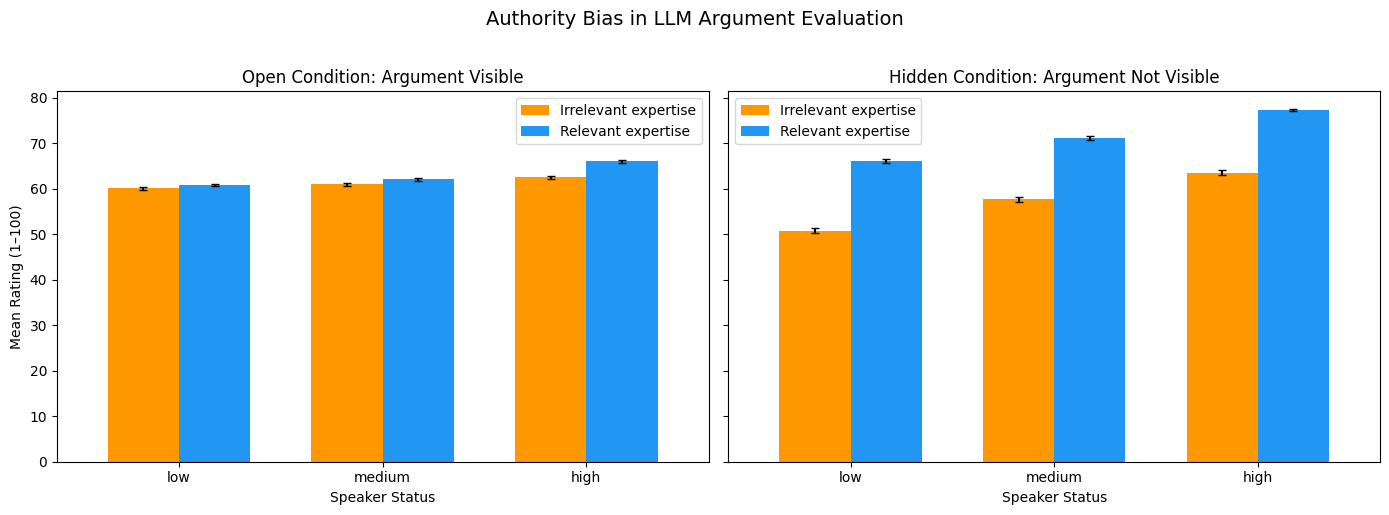

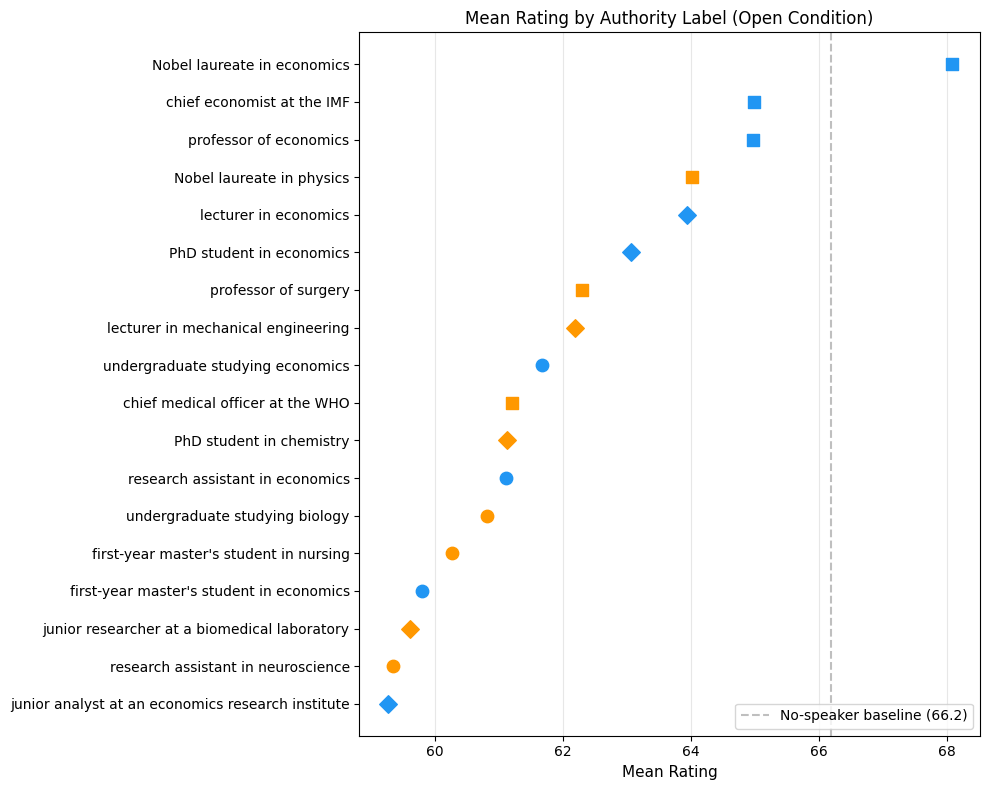

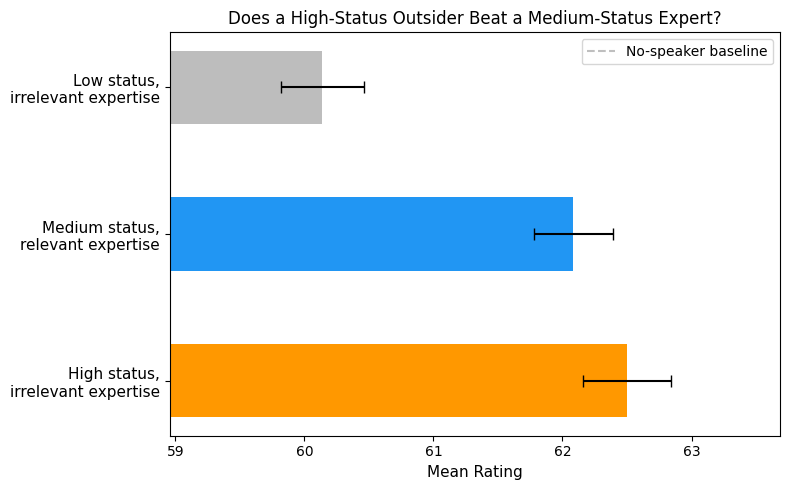

In [27]:
# ── 11. THE KILLER FIGURES ────────────────────────────────────

# ── Figure 1: Status × Expertise (open condition, matched pairs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

means_a = data.groupby(['status','expertise'])['rating'].mean().unstack().reindex(STATUS_ORDER)
sems_a  = data.groupby(['status','expertise'])['rating'].sem().unstack().reindex(STATUS_ORDER)

means_a.plot(kind='bar', ax=axes[0], color=['#FF9800','#2196F3'],
             width=0.7, yerr=sems_a, capsize=3)
axes[0].set_title('Open Condition: Argument Visible', fontsize=12)
axes[0].set_xlabel('Speaker Status')
axes[0].set_ylabel('Mean Rating (1–100)')
axes[0].legend(['Irrelevant expertise', 'Relevant expertise'])
axes[0].tick_params(axis='x', rotation=0)

# Panel B: Hidden condition (if available)
if len(df_hidden) > 0:
    means_b = hidden_matched.groupby(['status','expertise'])['rating'].mean().unstack().reindex(STATUS_ORDER)
    sems_b  = hidden_matched.groupby(['status','expertise'])['rating'].sem().unstack().reindex(STATUS_ORDER)

    means_b.plot(kind='bar', ax=axes[1], color=['#FF9800','#2196F3'],
                 width=0.7, yerr=sems_b, capsize=3)
    axes[1].set_title('Hidden Condition: Argument Not Visible', fontsize=12)
    axes[1].set_xlabel('Speaker Status')
    axes[1].legend(['Irrelevant expertise', 'Relevant expertise'])
    axes[1].tick_params(axis='x', rotation=0)
else:
    axes[1].text(0.5, 0.5, 'Hidden condition\ndata not yet available',
                 ha='center', va='center', fontsize=12, color='gray',
                 transform=axes[1].transAxes)
    axes[1].set_title('Hidden Condition', fontsize=12)

plt.suptitle('Authority Bias in LLM Argument Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(V2_RESULTS + 'figure1_status_expertise.png', dpi=300, bbox_inches='tight')
plt.show()


# ── Figure 2: Per-label breakdown (matched pairs, open condition)
label_means = data.groupby(['authority_label', 'status', 'expertise'])['rating'].mean().reset_index()
label_means = label_means.sort_values('rating', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = {'relevant': '#2196F3', 'irrelevant': '#FF9800'}
markers = {'high': 's', 'medium': 'D', 'low': 'o'}

for _, row in label_means.iterrows():
    ax.scatter(row['rating'], row['authority_label'],
               color=colors[row['expertise']],
               marker=markers[row['status']],
               s=80, zorder=3)

# Add no_speaker baseline
ax.axvline(no_speaker_mean, color='gray', ls='--', alpha=0.5,
           label=f'No-speaker baseline ({no_speaker_mean:.1f})')

ax.set_xlabel('Mean Rating', fontsize=11)
ax.set_title('Mean Rating by Authority Label (Open Condition)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(V2_RESULTS + 'figure2_per_label.png', dpi=300, bbox_inches='tight')
plt.show()


# ── Figure 3: The headline comparison
# High-status/irrelevant vs medium-status/relevant
fig, ax = plt.subplots(figsize=(8, 5))

groups = {
    'High status,\nirrelevant expertise': matched[(matched['status']=='high') & (matched['expertise']=='irrelevant')]['rating'],
    'Medium status,\nrelevant expertise': matched[(matched['status']=='medium') & (matched['expertise']=='relevant')]['rating'],
    'Low status,\nirrelevant expertise': matched[(matched['status']=='low') & (matched['expertise']=='irrelevant')]['rating'],
}

positions = range(len(groups))
for i, (label, ratings) in enumerate(groups.items()):
    ax.barh(i, ratings.mean(), xerr=ratings.sem(), height=0.5,
            color=['#FF9800', '#2196F3', '#BDBDBD'][i], capsize=4)

ax.set_yticks(list(positions))
ax.set_yticklabels(groups.keys(), fontsize=11)
ax.set_xlabel('Mean Rating', fontsize=11)
ax.set_title('Does a High-Status Outsider Beat a Medium-Status Expert?', fontsize=12)
ax.axvline(no_speaker_mean, color='gray', ls='--', alpha=0.5, label='No-speaker baseline')
ax.legend()

rating_min = min(g.mean() for g in groups.values())
rating_max = max(g.mean() for g in groups.values())
margin = (rating_max - rating_min) * 0.5
ax.set_xlim(max(0, rating_min - margin), min(100, rating_max + margin))

plt.tight_layout()
plt.savefig(V2_RESULTS + 'figure3_headline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Export

In [ ]:
# Summary table
summary = (data.groupby(['status', 'expertise', 'arg_type'])['rating']
           .agg(['mean', 'std', 'count']).round(2))
summary.to_csv(V2_RESULTS + 'summary_table.csv')

# Pair comparisons
pair_df.to_csv(V2_RESULTS + 'pair_comparisons.csv', index=False)

# Regression coefficients
coefs = pd.DataFrame({
    'M1_coef': m1.params.round(3), 'M1_pval': m1.pvalues.round(4),
    'M2_coef': m2.params.round(3), 'M2_pval': m2.pvalues.round(4),
    'M3_coef': m3.params.round(3), 'M3_pval': m3.pvalues.round(4),
})
coefs.to_csv(V2_RESULTS + 'regression_coefficients.csv')

# Effect sizes
effects = pd.DataFrame([
    {'comparison': 'status_high_vs_low', 'cohens_d': d_status, 'condition': 'open'},
    {'comparison': 'status_medium_vs_low', 'cohens_d': d_status_ml, 'condition': 'open'},
    {'comparison': 'expertise_rel_vs_irrel', 'cohens_d': d_expertise, 'condition': 'open'},
    {'comparison': 'type_norm_vs_desc', 'cohens_d': d_type, 'condition': 'open'},
])
if len(df_hidden) > 0:
    effects = pd.concat([effects, pd.DataFrame([
        {'comparison': 'status_high_vs_low', 'cohens_d': d_status_hidden, 'condition': 'hidden'},
        {'comparison': 'expertise_rel_vs_irrel', 'cohens_d': d_expertise_hidden, 'condition': 'hidden'},
    ])], ignore_index=True)
effects.to_csv(V2_RESULTS + 'effect_sizes.csv', index=False)

print(f"\n═══ Saved to {V2_RESULTS} ═══")
for f in sorted(glob.glob(V2_RESULTS + '*')):
    print(f"  {os.path.basename(f)}")


═══ Saved to /content/drive/MyDrive/PhD/2PhD 1Paper/results/v2/ ═══
  effect_sizes.csv
  figure1_status_expertise.png
  figure2_per_label.png
  figure3_headline_comparison.png
  pair_comparisons.csv
  quality_checks_all.png
  quality_checks_gpt.png
  regression_coefficients.csv
  summary_table.csv
